# Summary statistics for the comments dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from database.comments import Comments

There are two datasets loaded here - the dataset of all planning applciation IDs for 2021 onwards across the 8 relevant london councils. Plus the comments dataset - which is the free-text comments we've been able to scrape from the council websites. 

In [2]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

There are 5850 applications in the dataset.


In [3]:
# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

There are 5077 applications in the dataset after dropping Bromley applications.


In [4]:
# format 'borough' column so 'City of London' not 'City Of London'
application_df['borough'] = application_df['borough'].replace({'City Of London':'City of London'})

In [5]:
# Comments dataset
cs = Comments()
df = cs.read_all()
df = df.copy()
df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,78790,Ealing,230384FUL_16,230384FUL,2 Tring Avenue London W5 3QA W5 3QA,Objects,2023-02-27,This development is out of keeping with the ar...,2025-04-08,51.50873,-0.28956,This development is out of keeping with the ar...,E09000009,-0.596320
1,98844,Barnet,21/3676/FUL_537,21/3676/FUL,7 Park Road New Barnet EN4 9QA,Objects,2021-08-30,Dear Sirs\nI wish to register my objection to ...,2025-04-11,51.65192,-0.16772,Dear Sirs\nI wish to register my objection to ...,E09000003,-0.247984
2,76145,Lambeth,21/03147/FUL_6,21/03147/FUL,None,Objects,2022-08-02,The applicant proposes green/blue roofs and pe...,2025-04-08,NaN,NaN,The applicant proposes green/blue roofs and pe...,None,-0.231393
3,78796,Ealing,230384FUL_22,230384FUL,18 Tring Avenue ealing W5 3QA W5 3QA,Objects,2023-02-23,this sort of development is not appropriate fo...,2025-04-08,51.50873,-0.28956,this sort of development is not appropriate fo...,E09000009,-0.451211
4,78789,Ealing,230384FUL_15,230384FUL,36 Tring Avenue Londdon W5 3QB W5 3QB,Objects,2023-02-27,"The development seems excessive for the area, ...",2025-04-08,51.50707,-0.28793,"The development seems excessive for the area, ...",E09000009,-0.484850


In [6]:
# format 'council' column so 'City of London' not 'City Of London'
df['council'] = df['council'].replace({'City Of London':'City of London'})

print(f"The councils in the dataset are: {df['council'].unique()}")

The councils in the dataset are: ['Ealing' 'Barnet' 'Lambeth' 'Westminster' 'Southwark' 'Brent' 'Newham'
 'City of London']


In [7]:
print(f"Total number of comments: {len(df)}")
print(f"Total number of applications (with comments scraped): {len(df.application_id.unique())}")

Total number of comments: 30393
Total number of applications (with comments scraped): 2453


In [8]:
df.groupby("application_id").size().describe()

count    2453.000000
mean       12.390135
std        42.732741
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       844.000000
dtype: float64

In [9]:
unique_app_counts = df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

# Get number of unique applications and comments per council
unique_app_counts = df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

# Rename for clarity
unique_app_counts.columns = ['council', 'no_applications_with_comments', 'total_comment_count']

# Compute mean number of comments per application
unique_app_counts['mean_comments_per_application'] = (
    unique_app_counts['total_comment_count'] / unique_app_counts['no_applications_with_comments']
)

unique_app_counts

,council,no_applications_with_comments,total_comment_count,mean_comments_per_application
0,Barnet,791,9172,11.595449
1,Brent,395,2419,6.124051
2,City of London,14,38,2.714286
3,Ealing,497,11592,23.323944
4,Lambeth,208,2587,12.437500
5,Newham,158,750,4.746835
6,Southwark,152,2488,16.368421
7,Westminster,238,1347,5.659664


In [10]:
count_df = application_df.groupby('borough').size()
count_df = pd.DataFrame(count_df).reset_index().rename(columns={0:'no_applications'})

In [11]:
count_df

,borough,no_applications
0,Barnet,1291
1,Brent,935
2,City of London,21
3,Ealing,1122
4,Lambeth,483
5,Newham,424
6,Southwark,308
7,Westminster,493


In [12]:
unique_app_counts = pd.merge(unique_app_counts, count_df, left_on='council', right_on='borough', how='left')
unique_app_counts.drop(columns=['borough'], inplace=True)

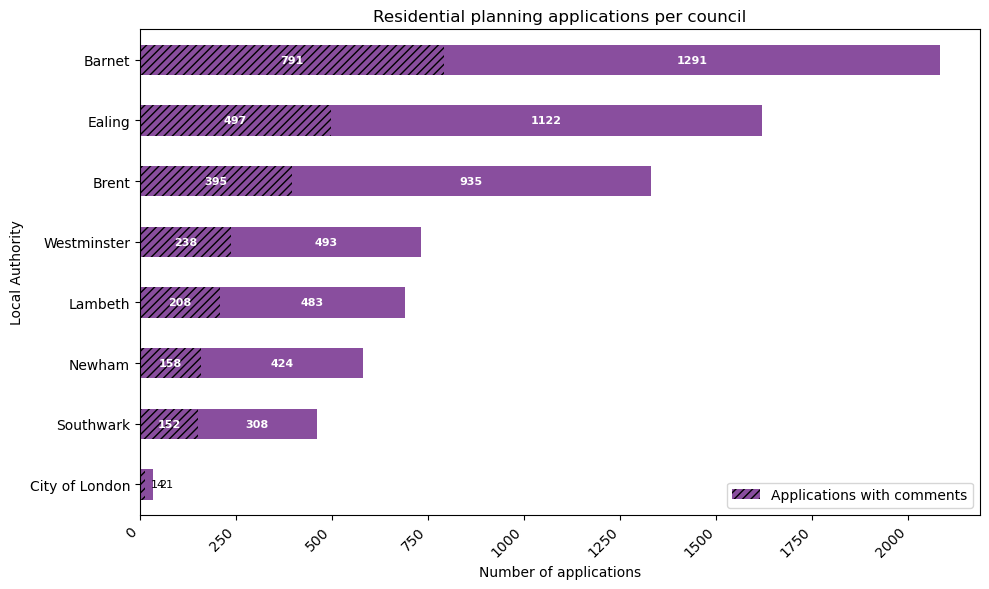

In [13]:
# Sort data
unique_app_counts = unique_app_counts.sort_values(by='no_applications', ascending=True)

# Create stacked bar chart with one color
ax = unique_app_counts.plot.barh(
    x='council',
    y=['no_applications_with_comments', 'no_applications'],
    stacked=True,
    figsize=(10,6),
    title='Residential planning applications per council',
    ylabel='Local Authority',
    xlabel='Number of applications',
    color=["#894e9e", '#894e9e']  # same color for both bars
)

# Apply hatching to the "with comments" bars
bars = ax.patches
n_councils = len(unique_app_counts)
for i, bar in enumerate(bars[:n_councils]):
    bar.set_hatch('////')

# Add text labels on each segment
for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    x = bar.get_x() + width / 2

    # If bar too narrow, place label to the right
    if width < unique_app_counts['no_applications'].max() * 0.08:
        ax.text(
            bar.get_x() + width + 15,  # push text to right
            y,
            f'{int(width)}',
            va='center',
            ha='left',
            fontsize=8,
            color='black'
        )
    else:
        ax.text(
            x,
            y,
            f'{int(width)}',
            va='center',
            ha='center',
            fontsize=8,
            color='white',
            fontweight='bold'
        )

# Only show legend for the hatched section
handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[0]], ['Applications with comments'], loc='lower right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


the number of comments vs. the number of residential units

In [14]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,78790,Ealing,230384FUL_16,230384FUL,2 Tring Avenue London W5 3QA W5 3QA,Objects,2023-02-27,This development is out of keeping with the ar...,2025-04-08,51.50873,-0.28956,This development is out of keeping with the ar...,E09000009,-0.596320
1,98844,Barnet,21/3676/FUL_537,21/3676/FUL,7 Park Road New Barnet EN4 9QA,Objects,2021-08-30,Dear Sirs\nI wish to register my objection to ...,2025-04-11,51.65192,-0.16772,Dear Sirs\nI wish to register my objection to ...,E09000003,-0.247984
2,76145,Lambeth,21/03147/FUL_6,21/03147/FUL,None,Objects,2022-08-02,The applicant proposes green/blue roofs and pe...,2025-04-08,NaN,NaN,The applicant proposes green/blue roofs and pe...,None,-0.231393
3,78796,Ealing,230384FUL_22,230384FUL,18 Tring Avenue ealing W5 3QA W5 3QA,Objects,2023-02-23,this sort of development is not appropriate fo...,2025-04-08,51.50873,-0.28956,this sort of development is not appropriate fo...,E09000009,-0.451211
4,78789,Ealing,230384FUL_15,230384FUL,36 Tring Avenue Londdon W5 3QB W5 3QB,Objects,2023-02-27,"The development seems excessive for the area, ...",2025-04-08,51.50707,-0.28793,"The development seems excessive for the area, ...",E09000009,-0.484850


In [15]:
app_count = df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

In [16]:
application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

In [17]:
application_df.head()

,lpa_app_no,valid_date,decision_date,borough,application_details.residential_details.total_no_proposed_residential_units,application_details.residential_details.total_no_affordable_units,application_details.residential_details.site_area,application_details.residential_details.habitable_rooms_density,pp_id,uprn,status,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description,comment_count
0,24/02204/FUL,2024-11-19 00:00:00,2025-03-25 00:00:00,Newham,1,NaN,NaN,NaN,PP-12728004,1.002400e+10,Approved,Approved,Falmouth Street,NaN,"2, 10",GEOMETRYCOLLECTION (POLYGON ((538894.0 185094....,"polygon=linearring(x=[0.001716, 0.001703, 0.00...",Proposed mansard roof extension to the main bu...,1
1,25/0089,2025-01-27 00:00:00,2025-03-24 00:00:00,Brent,1,NaN,NaN,NaN,PP-13670128,2.022052e+08,Approved,Approved,NaN,"92 Blenheim Gardens, London, NW2 4NT",NaN,NaN,NaN,Proposed change of use from HMO to a single dw...,0
2,24/1783,2024-08-05 00:00:00,2025-03-24 00:00:00,Brent,9,NaN,NaN,NaN,PP-12267268,2.021029e+08,Refused,Refused,NaN,"1 - 6 The Drive, London, NW10 3UB",NaN,NaN,NaN,Demolition of existing buildings and garages a...,5
3,25/00205/PRECOU,2025-02-03 00:00:00,2025-03-25 00:00:00,Newham,2,NaN,NaN,NaN,PP-13735437,1.000900e+10,NaN,Refused,Forest Lane,NaN,"176, 177",GEOMETRYCOLLECTION (POLYGON ((540475.0 185388....,"polygon=linearring(x=[0.024619, 0.024663, 0.02...",Prior Approval application for the change of u...,0
4,25/00181/PRECOU,2025-01-30 00:00:00,2025-03-26 00:00:00,Newham,1,NaN,NaN,NaN,PP-13687528,1.009348e+10,NaN,Refused,Sprowston Mews,NaN,66,GEOMETRYCOLLECTION (POLYGON ((540218.0 185015....,"polygon=linearring(x=[0.020766, 0.020563, 0.02...",Prior Approval application for the change of u...,1


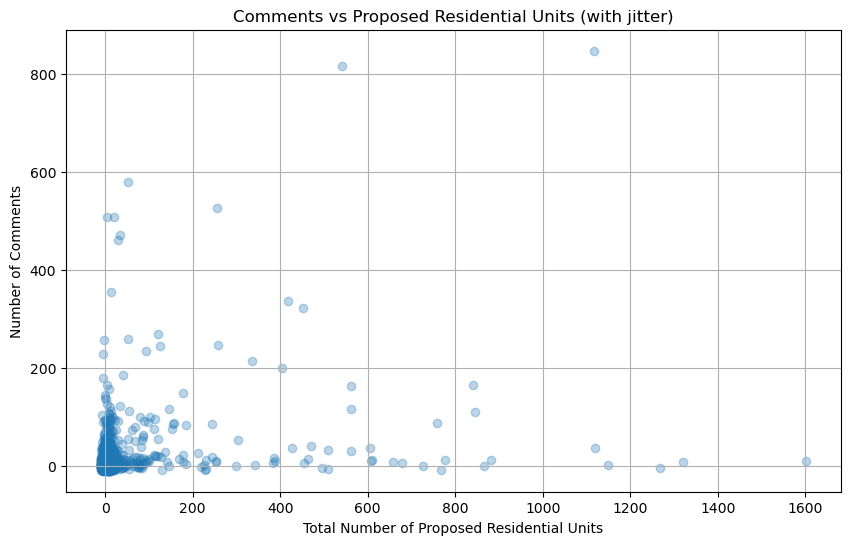

In [18]:
# scatter plot of comment count vs application_details.residential_details.total_no_proposed_residential_units in applictaion_df

with_comments = application_df[application_df['comment_count'] > 0]

# Filtered data
x = with_comments['application_details.residential_details.total_no_proposed_residential_units']
y = with_comments['comment_count']

# Add small additive jitter
x_jittered = x + np.random.uniform(-10, 10, size=len(x))  # adjust ±2 units as needed
y_jittered = y + np.random.uniform(-10, 10, size=len(y))  # adjust ±2 units as needed

plt.figure(figsize=(10,6))
plt.scatter(x_jittered, y_jittered, alpha=0.3)
plt.title('Comments vs Proposed Residential Units (with jitter)')
plt.xlabel('Total Number of Proposed Residential Units')
plt.ylabel('Number of Comments')
plt.grid(True)
plt.show()


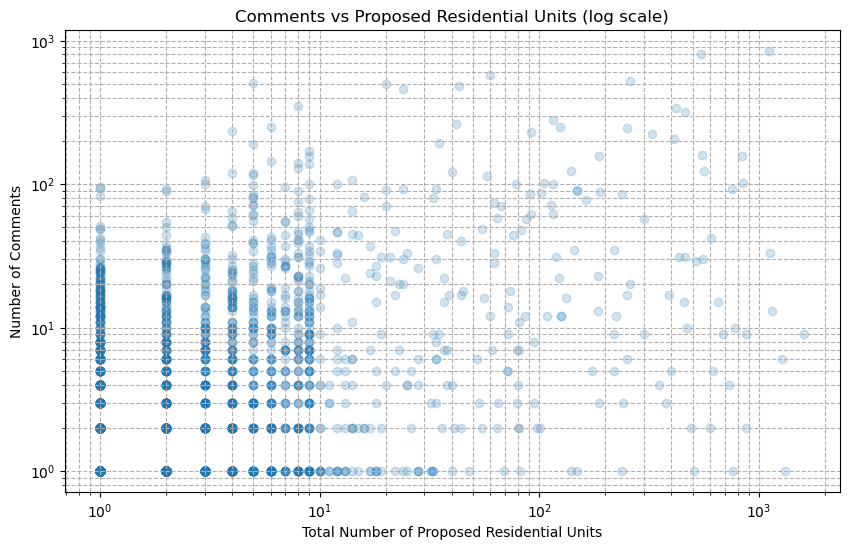

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(
    with_comments['application_details.residential_details.total_no_proposed_residential_units'],
    with_comments['comment_count'],
    alpha=0.2
)
plt.xscale('log')
plt.yscale('log')
plt.title('Comments vs Proposed Residential Units (log scale)')
plt.xlabel('Total Number of Proposed Residential Units')
plt.ylabel('Number of Comments')
plt.grid(True, which="both", ls="--")
plt.show()


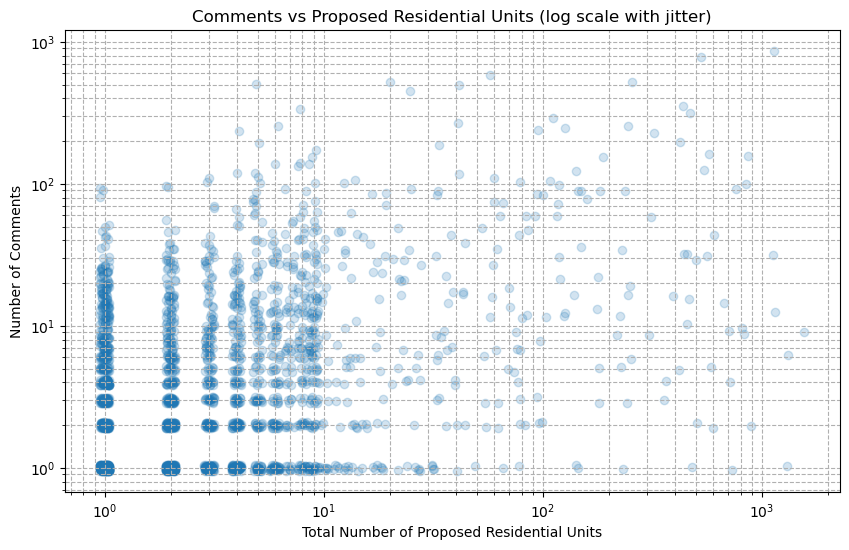

In [20]:
# Extract data
x = with_comments['application_details.residential_details.total_no_proposed_residential_units']
y = with_comments['comment_count']

# Add jitter: small fraction of the value
# For log scale, use multiplicative jitter
x_jittered = x * np.random.uniform(0.95, 1.05, size=len(x))
y_jittered = y * np.random.uniform(0.95, 1.05, size=len(y))

plt.figure(figsize=(10,6))
plt.scatter(x_jittered, y_jittered, alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.title('Comments vs Proposed Residential Units (log scale with jitter)')
plt.xlabel('Total Number of Proposed Residential Units')
plt.ylabel('Number of Comments')
plt.grid(True, which="both", ls="--")
plt.show()


### Plot histogram overlaying distribution of projects by residential units, with and without, comments

In [21]:
# create merged dataframe with comment counts

comments_df = df[['application_id', 'id']].groupby('application_id').count()
comments_df.reset_index(inplace=True)
comments_df.rename(columns={'id': 'comment_count'}, inplace=True)

merged_df = pd.merge(application_df, comments_df, left_on='lpa_app_no', right_on='application_id', how='left')
merged_df['comment_count'] = merged_df['comment_count'].replace(np.nan, 0)

KeyError: 'comment_count'

In [ ]:
merged_df.head()

In [ ]:
# bin and count the data 

# the total counts of proposed residential units
total_counts, total_bins = np.histogram(merged_df['application_details.residential_details.total_no_proposed_residential_units'], bins=40)
total_counts = np.log(total_counts + 1)  # Apply log transformation to counts for better visualization

# the total counts of proposed residential units with > 0 comments 
comment_counts, comment_bins = np.histogram(
    merged_df[merged_df['comment_count'] > 0]['application_details.residential_details.total_no_proposed_residential_units'], 
    bins=40
)
comment_counts = np.log(comment_counts + 1)  # Apply log transformation to counts for better visualization

In [ ]:
# Plotting the histogram overlaying the distributions

plt.figure(figsize=(12, 6))
plt.stairs(total_counts, total_bins, fill=True, label='All Applications', color='cornflowerblue', alpha=0.9)
plt.stairs(comment_counts, comment_bins, fill=True, label='Applications with comments', color='plum', alpha=0.9)
plt.xlabel('Number of proposed residential units')
plt.ylabel('Log of number of applications')
plt.title('Distribution of number of proposed residential units')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# mean number of comments per application accoutning for applications with no comments
mean_comments_per_application = len(df) / len(application_df.pp_id.unique())
print(f"Mean number of comments per application: {mean_comments_per_application:.2f}")

In [ ]:
apps_with_no_comments = len(application_df.pp_id.unique()) - len(df.application_id.unique())
print(f"Number of applications with no comments: {apps_with_no_comments}")
print(f"Number of applications with comments: {len(df.application_id.unique())}")

# median number of comments per application accoutning for applications with no comments
# Create a DataFrame with all applications and their comment counts
comment_counts = df.groupby('application_id').size().reset_index(name='comment_count')
# Merge with the application DataFrame to include all applications
application_counts = application_df[['pp_id']].rename(columns={'pp_id': 'application_id'})
merged_counts = comment_counts.merge(application_counts, on='application_id', how='left').fillna(0)
# Calculate the median of comment counts
median_comments_per_application = merged_counts['comment_count'].median()
print(f"Median number of comments per application: {median_comments_per_application:.2f}")                                                        

In [ ]:
# groupby application_id and stance
df_grouped = df.groupby(["application_id", "stance"]).size().reset_index(name='count')

df_grouped.head()

In [ ]:
# Total count per application
total_counts = df_grouped.groupby('application_id')['count'].sum().rename('total')

# Count per stance per application
object_counts = df_grouped[df_grouped['stance'] == 'Objects'].groupby('application_id')['count'].sum().rename('objects')
support_counts = df_grouped[df_grouped['stance'] == 'Supports'].groupby('application_id')['count'].sum().rename('supports')
neutral_counts = df_grouped[df_grouped['stance'] == 'Neutral'].groupby('application_id')['count'].sum().rename('neutral')

# Combine all above together
summary = pd.concat([total_counts, object_counts, support_counts, neutral_counts], axis=1).fillna(0)

# Compute percentages
summary['object_percent'] = (summary['objects'] / summary['total']) * 100
summary['support_percent'] = (summary['supports'] / summary['total']) * 100
summary['neutral_percent'] = (summary['neutral'] / summary['total']) * 100

# Descriptive stats (mean)
mean_object_percent = summary['object_percent'].mean()
mean_support_percent = summary['support_percent'].mean()
mean_neutral_percent = summary['neutral_percent'].mean()

print(f"Mean % of objections per application: {mean_object_percent:.2f}%")
print(f"Mean % of supports per application: {mean_support_percent:.2f}%")
print(f"Mean % of neutrals per application: {mean_neutral_percent:.2f}%")


In [ ]:
unique_app_counts = df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

# Get number of unique applications and comments per council
unique_app_counts = df.groupby('council')[['application_id', 'comment_id']].nunique().reset_index()

# Rename for clarity
unique_app_counts.columns = ['council', 'no_applications_with_comments', 'total_comment_count']

# Compute mean number of comments per application
unique_app_counts['mean_comments_per_application'] = (
    unique_app_counts['total_comment_count'] / unique_app_counts['no_applications_with_comments']
)

unique_app_counts

In [ ]:
df_council_count  = df[['council', 'stance']].groupby('council').value_counts().to_frame().reset_index()
df_council_count = df_council_count.pivot(index='council', columns='stance').reset_index()
df_council_count.columns = df_council_count.columns.droplevel(0)
df_council_count.columns = ['Council', 'Neutral', 'Objects', 'Supports']

In [ ]:
df_council_count

In [ ]:
councils = df_council_count['Council'].unique()

In [22]:
df_council_count.plot(
    x='Council',
    kind='bar',
    stacked=True,
    color={'Neutral': 'xkcd:cerulean', 'Objects': 'xkcd:pale red', 'Supports': 'xkcd:avocado'},
    figsize=(10, 6),
    # title='Comments Received by Council'
)
plt.xlabel('Council', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Stance')
plt.show()

NameError: name 'df_council_count' is not defined

In [27]:
london_lad = gpd.read_file('../data/Local_Authority_Districts_May_2024_London.geojson')

In [28]:
london_lad

,FID,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,geometry
0,264,E09000001,City of London,,532382,181358,-0.093510,51.5156,"POLYGON ((-0.09669 51.52319, -0.09668 51.52317..."
1,265,E09000002,Barking and Dagenham,,547757,185111,0.129479,51.5456,"POLYGON ((0.1481 51.59653, 0.14807 51.59636, 0..."
2,266,E09000003,Barnet,,523473,191752,-0.218190,51.6111,"POLYGON ((-0.19987 51.67017, -0.19968 51.66986..."
3,267,E09000004,Bexley,,549202,175434,0.146212,51.4582,"POLYGON ((0.15928 51.50871, 0.15997 51.50869, ..."
4,268,E09000005,Brent,,519615,186465,-0.275680,51.5644,"POLYGON ((-0.26482 51.59827, -0.2647 51.59817,..."
5,269,E09000006,Bromley,,542036,165707,0.039246,51.3727,"POLYGON ((0.03059 51.44432, 0.03063 51.4443, 0..."
6,270,E09000007,Camden,,527491,184283,-0.162910,51.5430,"POLYGON ((-0.16598 51.57274, -0.16589 51.57272..."
7,271,E09000008,Croydon,,533922,164745,-0.077610,51.3660,"POLYGON ((-0.11136 51.42317, -0.11093 51.42315..."
8,272,E09000009,Ealing,,517055,181959,-0.314100,51.5244,"POLYGON ((-0.34553 51.55843, -0.34551 51.55843..."
9,273,E09000010,Enfield,,532831,196198,-0.081440,51.6489,"POLYGON ((-0.10576 51.69188, -0.10574 51.69182..."


In [29]:
unique_app_counts

,council,no_applications_with_comments,total_comment_count,mean_comments_per_application,no_applications
2,City of London,14,38,2.714286,21
6,Southwark,152,2488,16.368421,308
5,Newham,158,750,4.746835,424
4,Lambeth,208,2587,12.437500,483
7,Westminster,238,1347,5.659664,493
1,Brent,395,2419,6.124051,935
3,Ealing,497,11592,23.323944,1122
0,Barnet,791,9172,11.595449,1291


In [30]:
london_lad_counts = pd.merge(
    london_lad,
    unique_app_counts,
    left_on='LAD24NM',
    right_on='council',
    how='left'
)

In [31]:
london_lad_counts.head()

,FID,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,geometry,council,no_applications_with_comments,total_comment_count,mean_comments_per_application,no_applications
0,264,E09000001,City of London,,532382,181358,-0.093510,51.5156,"POLYGON ((-0.09669 51.52319, -0.09668 51.52317...",City of London,14.0,38.0,2.714286,21.0
1,265,E09000002,Barking and Dagenham,,547757,185111,0.129479,51.5456,"POLYGON ((0.1481 51.59653, 0.14807 51.59636, 0...",NaN,NaN,NaN,NaN,NaN
2,266,E09000003,Barnet,,523473,191752,-0.218190,51.6111,"POLYGON ((-0.19987 51.67017, -0.19968 51.66986...",Barnet,791.0,9172.0,11.595449,1291.0
3,267,E09000004,Bexley,,549202,175434,0.146212,51.4582,"POLYGON ((0.15928 51.50871, 0.15997 51.50869, ...",NaN,NaN,NaN,NaN,NaN
4,268,E09000005,Brent,,519615,186465,-0.275680,51.5644,"POLYGON ((-0.26482 51.59827, -0.2647 51.59817,...",Brent,395.0,2419.0,6.124051,935.0


In [32]:
from matplotlib.colors import LinearSegmentedColormap

# Define your target blue in hex
target_blue = "#1f77b4"  # Replace this with your desired hex color

# Create the custom colormap
white_to_blue = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#1f77b4"])


In [33]:
def assign_side(row, minx, maxx, miny, maxy):
    x, y = row['centroid_x'], row['centroid_y']
    # Calculate distances to each edge
    dist_left = abs(x - minx)
    dist_right = abs(maxx - x)
    dist_bottom = abs(y - miny)
    dist_top = abs(maxy - y)

    # Assign side by minimum distance to bounding box edge
    distances = {'left': dist_left, 'right': dist_right, 'top': dist_top, 'bottom': dist_bottom}
    assigned_side = min(distances, key=distances.get)
    return assigned_side


In [34]:
# Bounding box
minx, miny, maxx, maxy = london_lad_counts.total_bounds
x_margin = (maxx - minx) * 0.05
y_margin = (maxy - miny) * 0.05

highlighted = london_lad_counts[london_lad_counts['LAD24NM'].isin(councils)].copy()
highlighted['centroid'] = highlighted.geometry.centroid

# Sort based on y or x using `.apply()` to extract coords
highlighted['centroid_x'] = highlighted['centroid'].apply(lambda point: point.x)
highlighted['centroid_y'] = highlighted['centroid'].apply(lambda point: point.y)

highlighted['side'] = highlighted.apply(assign_side, axis=1, args=(minx, maxx, miny, maxy))

NameError: name 'councils' is not defined

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
london_lad_counts.plot(ax=ax, 
                       column='total_comment_count',
                       legend=False,
                       scheme='quantiles',
                       cmap='Oranges',
                       edgecolor='dimgrey',
                       figsize=(12, 8),
                       missing_kwds={'color': 'lightgrey',
                                     "edgecolor": "grey",
                                     "hatch": "///",
                                     "label": "No data"})

# # add council name for 'highlight'
# for x, y, label in zip(london_lad_counts.geometry.centroid.x, london_lad_counts.geometry.centroid.y, london_lad['LAD24NM']):
#     if label in councils:
#         ax.text(x, y, label, fontsize=8, ha='center', va='center', color='black')


# Add comment count inside each polygon (centroid-based)
for idx, row in london_lad_counts.iterrows():
    if pd.notnull(row['total_comment_count']):
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            f"n={int(row['total_comment_count'])}",  # Or use row['total_comment_count'] directly for full values
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )


def annotate_side(df, side):
    # Sort the df by coordinate axis to get label order
    if side in ['left', 'right']:
        df = df.sort_values(by='centroid_y')  # south → north
    else:  # 'top' or 'bottom'
        df = df.sort_values(by='centroid_x')  # west → east
    
    n = len(df)
    if side in ['left', 'right']:
        # evenly space labels vertically
        y_positions = np.linspace(miny, maxy, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'left':
                lx, ly = minx - x_margin, y_positions[i]
                ha, va = 'right', 'center'
            else:  # right
                lx, ly = maxx + x_margin, y_positions[i]
                ha, va = 'left', 'center'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )
    else:
        # evenly space labels horizontally
        x_positions = np.linspace(minx, maxx, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'top':
                lx, ly = x_positions[i], maxy + y_margin
                ha, va = 'center', 'bottom'
            else:  # bottom
                lx, ly = x_positions[i], miny - y_margin
                ha, va = 'center', 'top'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=10,
                ha=ha,
                va=va,
                color='black'
            )

for side, group in highlighted.groupby('side'):
    annotate_side(group, side)

ax.set_axis_off()

In [ ]:
# # Create a new column to indicate if the council is in the councils array
# london_lad['highlight'] = london_lad['LAD24NM'].apply(lambda x: x in councils)

# # Plot the GeoDataFrame
# fig, ax = plt.subplots(1, 1, figsize=(12, 8))
# london_lad.plot(ax=ax, color='lightgrey', edgecolor='black')  # Default color for all areas
# london_lad[london_lad['highlight']].plot(ax=ax, color='orange', edgecolor='black')  # Highlighted councils
# # add council name for 'highlight'
# for x, y, label in zip(london_lad.geometry.centroid.x, london_lad.geometry.centroid.y, london_lad['LAD24NM']):
#     if label in councils:
#         ax.text(x, y, label, fontsize=8, ha='center', va='center', color='black')

# ax.set_axis_off()

# # Add title and legend
# ax.set_title('Highlighted Councils in London', fontsize=16)
# plt.show()